In [1219]:
import random
import pygad
import networkx as nx
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np


In [1220]:
def read_graph(file_path):
    graph = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()

    num_nodes = int(lines[0].strip())
    for node in range (1, num_nodes + 1):
        graph[node] = []

    for line in lines[1:]:
        parts = line.strip().split()
        if(len(parts) != 3):
            continue

        start = int(parts[0])
        finish = int(parts[1])
        distance = int(parts[2])

        graph[start].append((finish, distance))
    return graph

In [1221]:
graph3 = read_graph("graph3.txt")
graph3


{1: [(2, 5), (3, 3), (4, 8)],
 2: [(5, 2), (6, 7)],
 3: [(6, 4), (7, 6)],
 4: [(7, 3), (8, 9)],
 5: [(9, 3), (10, 6)],
 6: [(10, 2), (11, 7)],
 7: [(11, 4), (12, 3)],
 8: [(12, 5)],
 9: [(13, 4)],
 10: [(13, 1), (14, 8)],
 11: [(14, 3), (15, 6)],
 12: [(15, 2)],
 13: [(16, 7)],
 14: [(16, 3)],
 15: [(16, 5)],
 16: [(17, 4)],
 17: [(18, 3)],
 18: [(19, 2)],
 19: [(20, 1)],
 20: []}

In [1222]:
def graph_visualization(graph):
    G = nx.DiGraph()
    for node, value in graph.items():
        for nxt, distance in value:
            G.add_edge(node, nxt, weight=distance)

    pos = nx.spring_layout(G, k=5, iterations=100)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=1, arrowstyle='-|>', arrowsize=7)


    nx.draw_networkx_labels(G, pos, font_size=6, font_color='black')


    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5)

    plt.axis('off')
    plt.show()


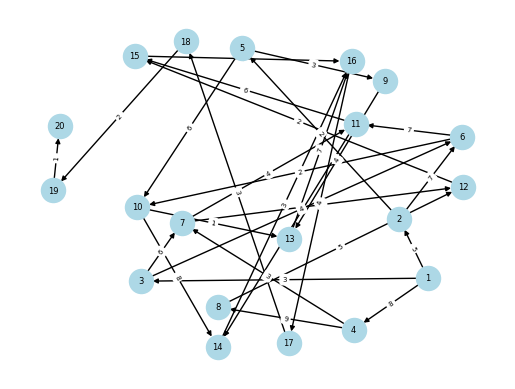

In [1223]:
graph_visualization(graph3)

In [1224]:
def path_distance(path, graph):
    result = 0

    for i in range(len(path) - 1):
        current_node = path[i]
        next_node = path[i+1]
        neighbors = graph[current_node]

        distance = None
        for(f, d) in neighbors:
            if f == next_node:
                distance = d
                break

        if distance is None:
            return None

        result += distance

    return result

In [1225]:
path1 = [1, 3, 4, 5]
path2 = [1, 4, 5]

print("path1:", path_distance(path1, graph3))
print("path2:", path_distance(path2, graph3))

path1: None
path2: None


In [1226]:
def generate_path(start, end, graph, max_steps = 100):
    current = start
    path = [current]

    for _ in range(max_steps):
        if current == end:
            return path

        neighbors = graph[current]
        if not neighbors:
            return None

        next_node, _ = random.choice(neighbors)
        path.append(next_node)
        current = next_node

    if current == end:
        return path
    else:
        return None

In [1227]:
for i in range(10):
    p = generate_path(1, 20, graph3)
    print(p, " -> distance:", path_distance(p, graph3) if p is not None else None)

[1, 4, 8, 12, 15, 16, 17, 18, 19, 20]  -> distance: 39
[1, 4, 7, 11, 15, 16, 17, 18, 19, 20]  -> distance: 36
[1, 2, 6, 11, 15, 16, 17, 18, 19, 20]  -> distance: 40
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20]  -> distance: 39
[1, 3, 7, 12, 15, 16, 17, 18, 19, 20]  -> distance: 29
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20]  -> distance: 39
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20]  -> distance: 39
[1, 3, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 30
[1, 3, 7, 11, 15, 16, 17, 18, 19, 20]  -> distance: 34
[1, 2, 6, 11, 14, 16, 17, 18, 19, 20]  -> distance: 35


In [1228]:
def generate_initial_population(start, end , graph, population_size = 50):
    population = []
    attempts = 0

    while (len(population) < population_size and attempts < population_size * 10):
        path = generate_path(start, end, graph)

        if path is not None:
            population.append(path)

        attempts += 1
    return population

In [1229]:
population = generate_initial_population(1, 20, graph3, population_size=15)
population

[[1, 4, 7, 12, 15, 16, 17, 18, 19, 20],
 [1, 4, 7, 11, 15, 16, 17, 18, 19, 20],
 [1, 2, 6, 11, 14, 16, 17, 18, 19, 20],
 [1, 2, 5, 9, 13, 16, 17, 18, 19, 20],
 [1, 3, 7, 11, 14, 16, 17, 18, 19, 20],
 [1, 3, 6, 10, 13, 16, 17, 18, 19, 20],
 [1, 3, 6, 10, 13, 16, 17, 18, 19, 20],
 [1, 2, 6, 10, 13, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 15, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 15, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 14, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 2, 6, 11, 14, 16, 17, 18, 19, 20],
 [1, 2, 5, 9, 13, 16, 17, 18, 19, 20],
 [1, 2, 5, 10, 14, 16, 17, 18, 19, 20]]

In [1230]:
def fitness(path, graph, start, end):
    if path is None:
        return 1e9

    if path[0] != start or path[-1] != end:
        return 1e9

    dist = path_distance(path, graph)

    if dist is None:
        return 1e9

    return dist

In [1231]:
start = 1
end = 20

pop = generate_initial_population(start, end, graph3, population_size=5)

for p in pop:
    print(p, "fitness:", fitness(p, graph3, start, end))


[1, 3, 6, 10, 14, 16, 17, 18, 19, 20] fitness: 30
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20] fitness: 39
[1, 2, 6, 10, 13, 16, 17, 18, 19, 20] fitness: 32
[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31
[1, 3, 6, 11, 14, 16, 17, 18, 19, 20] fitness: 30


In [1232]:
def tournament_selection(population, fitnesses, tournament_size = 3):
    indices = random.sample(range(len(population)), tournament_size)
    best_idx = min(indices, key=lambda i: fitnesses[i])

    return population[best_idx]

In [1233]:
start = 1
end = 20
population = generate_initial_population(start, end, graph3, population_size=10)
fitnesses = [fitness(p, graph3, start, end) for p in population]

print("POPULACIJA:")
for p, f in zip(population, fitnesses):
    print(p, "fitness:", f)

print("\nIZBRAN STARŠ:")
parent = tournament_selection(population, fitnesses, tournament_size=3)
print(parent, "fitness:", fitness(parent, graph3, start, end))


POPULACIJA:
[1, 2, 5, 9, 13, 16, 17, 18, 19, 20] fitness: 31
[1, 3, 6, 11, 15, 16, 17, 18, 19, 20] fitness: 35
[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31
[1, 2, 6, 10, 13, 16, 17, 18, 19, 20] fitness: 32
[1, 2, 5, 9, 13, 16, 17, 18, 19, 20] fitness: 31
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20] fitness: 39
[1, 3, 7, 11, 15, 16, 17, 18, 19, 20] fitness: 34
[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31
[1, 3, 7, 11, 15, 16, 17, 18, 19, 20] fitness: 34
[1, 2, 5, 10, 14, 16, 17, 18, 19, 20] fitness: 34

IZBRAN STARŠ:
[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31


In [1234]:
def mutate(path, graph, mutation_probability = 0.1):
    new_path = path[:]

    for i in range(len(new_path) - 1):
        if random.random() < mutation_probability:
            current = new_path[i]
            neighbors = graph[current]

            if not neighbors:
                continue

            next_node, _ = random.choice(neighbors)
            new_path[i + 1] = next_node

    return new_path

In [1235]:
p = population[0]
print("Original:", p)

mutated = mutate(p, graph3, mutation_probability=0.5)
print("Mutated: ", mutated)

print("Fitness original:", fitness(p, graph3, start, end))
print("Fitness mutated: ", fitness(mutated, graph3, start, end))


Original: [1, 2, 5, 9, 13, 16, 17, 18, 19, 20]
Mutated:  [1, 4, 8, 12, 13, 16, 17, 18, 19, 20]
Fitness original: 31
Fitness mutated:  1000000000.0


In [1236]:
def single_point_crossover(parent1, parent2):
    if len(parent1) < 3 or len(parent2) < 3:
        return parent1[:], parent2[:]

    cut1 = random.randint(1, len(parent1) - 2)
    cut2 = random.randint(1, len(parent2) - 2)

    child1 = parent1[:cut1] + parent2[cut2:]
    child2 = parent2[:cut2] + parent1[cut1:]

    return child1, child2

In [1237]:
start = 1
end = 20

population = generate_initial_population(start, end, graph3, population_size=4)
fitnesses = [fitness(p, graph3, start, end) for p in population]

print("STARŠI:")
for p, f in zip(population, fitnesses):
    print(p, "fitness:", f)

# izberemo 2 starša
parent1 = tournament_selection(population, fitnesses, tournament_size=3)
parent2 = tournament_selection(population, fitnesses, tournament_size=3)

print("\nIZBRAN STARŠ 1:", parent1)
print("IZBRAN STARŠ 2:", parent2)

child1, child2 = single_point_crossover(parent1, parent2)

print("\nOTROCI:")
print("child1:", child1, "fitness:", fitness(child1, graph3, start, end))
print("child2:", child2, "fitness:", fitness(child2, graph3, start, end))


STARŠI:
[1, 2, 6, 10, 13, 16, 17, 18, 19, 20] fitness: 32
[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31
[1, 3, 7, 11, 15, 16, 17, 18, 19, 20] fitness: 34
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20] fitness: 39

IZBRAN STARŠ 1: [1, 4, 7, 12, 15, 16, 17, 18, 19, 20]
IZBRAN STARŠ 2: [1, 4, 7, 12, 15, 16, 17, 18, 19, 20]

OTROCI:
child1: [1, 4, 7, 12, 15, 17, 18, 19, 20] fitness: 1000000000.0
child2: [1, 4, 7, 12, 15, 16, 16, 17, 18, 19, 20] fitness: 1000000000.0


In [1238]:
def genetic_algorithm(start, end, graph, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3):
    population = generate_initial_population(start, end, graph, population_size)
    best_path = None
    best_fitness = float("inf")

    for gen in range(generations):
        fitnesses = [fitness(p, graph, start, end) for p in population]

        gen_best_idx = min(range(len(population)), key=lambda i: fitnesses[i])
        gen_best_path = population[gen_best_idx]
        gen_best_fitness = fitnesses[gen_best_idx]

        if gen_best_fitness < best_fitness:
            best_fitness = gen_best_fitness
            best_path = gen_best_path

        new_population = []
        new_population.append(best_path)

        while len(new_population) < population_size:
            # izberi starše
            parent1 = tournament_selection(population, fitnesses, tournament_size)
            parent2 = tournament_selection(population, fitnesses, tournament_size)

            # crossover
            child1, child2 = single_point_crossover(parent1, parent2)

            # mutacija
            child1 = mutate(child1, graph, mutation_probability)
            child2 = mutate(child2, graph, mutation_probability)
            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_path, best_fitness


In [1239]:
start = 1
end = 20

best_path, best_fit = genetic_algorithm(start, end, graph3, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3)

print("Najdena pot:", best_path)
print("Dolžina poti:", best_fit)


Najdena pot: [1, 3, 6, 10, 13, 16, 17, 18, 19, 20]
Dolžina poti: 27


In [1240]:
def shortest_path(graph, start, end):
   
    distances = {node: 1e9 for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    
    
    unvisited = set(graph.keys())
    
    while unvisited:
        
        current_node = None
        min_distance = 1e9
        for node in unvisited:
            if distances[node] < min_distance:
                min_distance = distances[node]
                current_node = node
       


        
        if distances[current_node] == 1e9:
            break
        
    
        if current_node == end:
            break
        
        
        for neighbor, weight in graph[current_node]:
            new_distance = distances[current_node] + weight
            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                previous[neighbor] = current_node
        
        
        unvisited.remove(current_node)
    

    path = []
    node = end
    while node is not None:
        path.insert(0, node)
        node = previous[node]
    
    return path, distances[end]


In [1241]:
start = 1
end = 20

shortest_path_ga, distance_ga = genetic_algorithm(start, end, graph3, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3)

print("Najdena pot z ga:", shortest_path_ga)
print("Dolžina poti z ga:", distance_ga)

shortest_path, distance = shortest_path(graph3, start, end)

print("Najdena pot z dijkstro:", shortest_path)
print("Dolžina poti z dijkstro:", distance)




Najdena pot z ga: [1, 3, 6, 10, 13, 16, 17, 18, 19, 20]
Dolžina poti z ga: 27
Najdena pot z dijkstro: [1, 3, 6, 10, 13, 16, 17, 18, 19, 20]
Dolžina poti z dijkstro: 27


In [1242]:
def generate_path2(targets, graph):
    

   
    current = targets[0]
    path = [current]

        
    success = True
    
    
    for i in range(len(targets)-1):
        current = targets[i]
        nxt = targets[i+1]
        segment = [current]
        future_targets = []
        if (i+2 < len(targets)): 
            future_targets = set(targets[i+2:])
         

    
        while (segment[-1]!= nxt):
            
            possible_nodes =  [node for node, _ in graph.get(segment[-1], []) if node not in future_targets and node not in segment]

            
           
                
            if not possible_nodes:
                success = False
                break
   
            n = random.choice(possible_nodes)
            segment.append(n)

        if not success:
            break


        path.extend(segment[1:])
        if (i+2 < len(targets)): 
            future_targets.remove(targets[i+2])
    if success:
        return path 
    
    return []  

 

In [1243]:
for i in range(10):
    p = generate_path2([1, 14, 20], graph3)
    print(p, " -> distance:", path_distance(p, graph3))

[]  -> distance: 0
[1, 4, 7, 11, 14, 16, 17, 18, 19, 20]  -> distance: 31
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0


In [1244]:
def generate_initial_population2(targets, graph, population_size = 50)->np.ndarray:
    population = []
    attempts = 0
    fixed_length = len(graph)*5
    while (len(population) < population_size and attempts < population_size * 10):
        path = np.array(generate_path2(targets, graph))

        if path.size > 0 :
            population.append(path)

        attempts += 1
    if len(population) > 0:
        
        population = [np.pad(path, (0, fixed_length - len(path)), constant_values=-1) for path in population]
        
        
    return np.array(population)

In [1245]:
population2 = generate_initial_population2([1, 3, 19], graph3, population_size=15)
population2

array([[ 1,  3,  7, ..., -1, -1, -1],
       [ 1,  3,  7, ..., -1, -1, -1],
       [ 1,  3,  7, ..., -1, -1, -1],
       ...,
       [ 1,  3,  7, ..., -1, -1, -1],
       [ 1,  3,  7, ..., -1, -1, -1],
       [ 1,  3,  6, ..., -1, -1, -1]], shape=(15, 100))

In [1246]:
def make_fitness2(graph, targets):
    def fitness2(ga_instance, solution, solution_idx):

        if solution is None:
           
            return 1e-9
            
        if -1 in solution:
            solution = solution[solution != -1]

        solution_list = list(solution)
        it = iter(solution_list)
        if not (all(target in it for target in targets)):
            
            return 1e-9
            
        dist = path_distance(solution_list, graph)

        if dist is None:
            
            return 1e-9
            
        return 1.0/ (1.0+dist)
    
    return fitness2    

In [1247]:
fitness_fn = make_fitness2(graph3,  [1, 3, 19])

for p in population2:
    print(p, "fitness:", fitness_fn(None, p, None))


[ 1  3  7 12 15 16 17 18 19 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1] fitness: 0.034482758620689655
[ 1  3  7 11 15 16 17 18 19 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1] fitness: 0.029411764705882353
[ 1  3  7 12 15 16 17 18 19 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1] fitness: 0.03448275862

In [1248]:
def make_mutate2(graph, targets, mutation_probability = 0.1):

    fixed_length = len(graph)*5
   
    def mutate2(paths, ga_instance):
        new_paths =[]
        for path in paths:
            new_path = np.array(path)
        
            
            
            new_path = new_path[new_path != -1]
        
        
        
            for i in range(len(new_path) - 1):
                if new_path[i+1] in targets:
                    continue
                if random.random() < mutation_probability:
                    current = new_path[i]
                    neighbors = [n for n, _ in graph[current] if n not in targets]


                    if not neighbors:
                        continue
          
                    next_node = random.choice(neighbors)
                    new_path[i + 1] = next_node
    
            new_path = np.pad(new_path, (0, fixed_length-len(new_path)), constant_values=-1)
            new_paths.append(new_path)
        return np.array(new_paths)
    
    return mutate2

In [1249]:
p2 = population2[0]
print("Original:", p2)

mutate_fn = make_mutate2(graph3,  [1, 3, 19], 0.8)

mutated2 = mutate_fn([p2], None)
print("Mutated: ", mutated2)

print("Fitness original:", fitness_fn(None, p2, None))
print("Fitness mutated: ", fitness_fn(None, mutated2, None))


Original: [ 1  3  7 12 15 16 17 18 19 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
Mutated:  [[ 1  3  7 11 14 16 17 18 19 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1]]
Fitness original: 0.034482758620689655
Fitness mutated:  0.034482758620689655


In [1250]:
def split_into_segments(path, targets):
    path = np.array(path)
    path = path.tolist()
    segments = []
    start = 0
    end = 0
    i = 1
    for p in path[1:]:
        if len(targets) > i and targets[i] == p:
            
            i +=1
            end = path.index(p)
            segment = path[start:end+1]
            segments.append(segment)
            start = end
            
        

    return segments   



In [1251]:
path = population2[0]
print("Pot: ", path)
print ("Segmenti: " , split_into_segments(path, [1, 12, 17, 19]))

path = [1, 2, 5, 2, 7]
print("Pot: ", path)
print ("Segmenti: " , split_into_segments(path, [1, 2, 7]))


path = [
    1, 2, 3, 4, 5, 3, 6, 7, 8, 6, 9, 10, 11, 10, 12, 13, 14, 12, 15, 16,
    17, 16, 18, 19, 20, 18, 21, 22, 23, 21, 24, 25, 26, 24, 27, 28, 29, 27, 30
]


targets = [1, 6, 12, 18, 24, 30]

print("Pot: ", path)
print ("Segmenti: " , split_into_segments(path, [1, 6, 16, 30]))


Pot:  [ 1  3  7 12 15 16 17 18 19 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
Segmenti:  [[1, 3, 7, 12], [12, 15, 16, 17], [17, 18, 19]]
Pot:  [1, 2, 5, 2, 7]
Segmenti:  [[1, 2], [2, 5, 2, 7]]
Pot:  [1, 2, 3, 4, 5, 3, 6, 7, 8, 6, 9, 10, 11, 10, 12, 13, 14, 12, 15, 16, 17, 16, 18, 19, 20, 18, 21, 22, 23, 21, 24, 25, 26, 24, 27, 28, 29, 27, 30]
Segmenti:  [[1, 2, 3, 4, 5, 3, 6], [6, 7, 8, 6, 9, 10, 11, 10, 12, 13, 14, 12, 15, 16], [16, 17, 16, 18, 19, 20, 18, 21, 22, 23, 21, 24, 25, 26, 24, 27, 28, 29, 27, 30]]


In [1252]:
def make_crossover2(targets, graph):
    fixed_length = len(graph)*5
    def crossover2(parents, offspring_size, ga_instance):
        offspring, _ = offspring_size
        children = []
        for i in range(offspring):
            
            parent1 = np.array(parents[0])
            parent2 = np.array(parents[1])
            parent1 = parent1[parent1 != -1]
            parent2 = parent2[parent2 != -1]
        
           
            segments1 = split_into_segments(parent1, targets)
            segments2 = split_into_segments(parent2, targets)
            child_segments = [s1 if random.random() < 0.5 else s2 for s1, s2 in zip(segments1, segments2)]
    
            child = []
      
            for seg in child_segments:
                child.extend(seg[:-1])  

            child.append(targets[-1])
            child = np.array(child)
            child = np.pad(child, (0, fixed_length-len(child)), constant_values=-1)
           

            children.append(child)
           
        return np.array(children)

    return crossover2


In [1253]:
graph5 = read_graph("graph5.txt")
targets= [1, 7, 20]
population3 = generate_initial_population2(targets, graph5, population_size=5)
print(population3)
parents = [population3[0], population3[1]]

crossover_f = make_crossover2(targets, graph5)
children = crossover_f(parents, (3, None), None)

print("Starša: " , parents)
print("Otroci: " , children)




[[ 1  3  7 10 14 18 19 20 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1]
 [ 1  3  7 11 15 19 20 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1]
 [ 1  3  7 10 14 18 19 20 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1]
 [ 1  3  7 10 14 18 19 20 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1

In [1254]:





def shortest_path2(graph, targets):
    population = generate_initial_population2(targets, graph, population_size=10)

    ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=2,
    fitness_func=make_fitness2(graph, targets),
    sol_per_pop=10,
    num_genes=len(graph) *5,
    initial_population=population,
    parent_selection_type="tournament",
    crossover_type=make_crossover2(targets, graph),
    mutation_type=make_mutate2(graph, targets, 0.2),
    stop_criteria="saturate_15"
    
    )


    ga_instance.run()

   
    solution, fitness, _ = ga_instance.best_solution()
    
    solution = solution[solution != -1]
    return solution, fitness

   


In [1255]:
targets = [1, 7, 20]
solution, fitnes = shortest_path2(graph3, targets)
print("Best path:", solution)
print("Distance:", path_distance(solution, graph3))


Best path: [ 1.  3.  7. 12. 15. 16. 17. 18. 19. 20.]
Distance: 29


In [1256]:
def shortest_path2_1(graph, targets):
    population = generate_initial_population2(targets, graph, population_size=10)

    ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=3,
    fitness_func=make_fitness2(graph, targets),
    sol_per_pop=10,
    num_genes=len(graph) *5,
    initial_population=population,
    parent_selection_type="tournament",
    crossover_type=make_crossover2(targets, graph),
    mutation_type=make_mutate2(graph, targets, 0.2),
    stop_criteria="saturate_15"
    
    )


    ga_instance.run()

   
    solution, fitness, _ = ga_instance.best_solution()
    
    solution = solution[solution != -1]
    return solution, fitness

Generation 1: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 2: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 3: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 4: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 5: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 6: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 7: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 8: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 9: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]
Generation 10: Best fitness = 0.0333, Best path = [ 1.  4.  8. 12. 15. 16.]


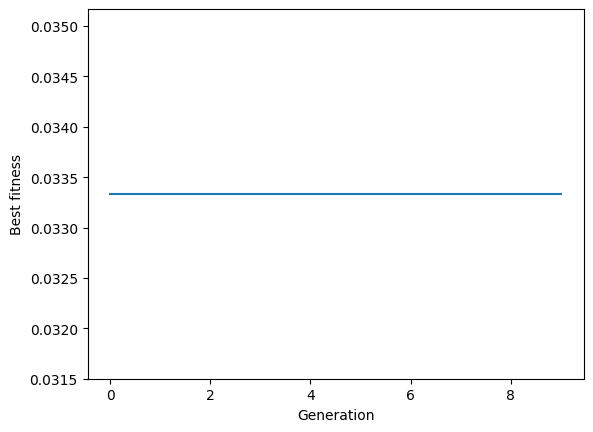

In [1257]:
targets = [1, 8,16]

history = []
def on_gen(ga_instance):
    
    best_solution = ga_instance.best_solution()[0]
    best_fitness = ga_instance.best_solution()[1]
    best_solution_clean = best_solution[best_solution != -1]
    print(f"Generation {ga_instance.generations_completed}: Best fitness = {best_fitness:.4f}, Best path = {best_solution_clean}")
    history.append(best_fitness)


population = generate_initial_population2(targets, graph3, population_size=10)


ga_i = pygad.GA(
    num_generations=10,
    num_parents_mating=2,
    fitness_func=make_fitness2(graph3, targets),
    sol_per_pop=2,
    num_genes=len(graph3) *5,
    initial_population=population,
    parent_selection_type="tournament",
    crossover_type=make_crossover2(targets, graph3),
    mutation_type=make_mutate2(graph3, targets, 0.5),
    stop_criteria="saturate_15",
    on_generation=on_gen
    
    )

ga_i.run()
plt.plot(history)
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.show()

